# Mutual Fund Analytics Platform
## Exploratory Data Analysis (EDA)

**Project:** Bluestock Fintech Capstone

### Objectives

- Analyze historical NAV trends
- Compare AUM growth across AMCs
- Study SIP inflows
- Analyze investor demographics
- Visualize geographic distribution
- Study category-wise inflows
- Explore portfolio sector allocation
- Identify key business insights

---

## 1. Imports

In [16]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

In [17]:
# Project Path

PROJECT_ROOT = Path.cwd().parent

RAW = PROJECT_ROOT / "data" / "raw"

CHART_DIR = PROJECT_ROOT / "reports" / "charts"
HTML_DIR = PROJECT_ROOT / "reports" / "interactive"

CHART_DIR.mkdir(exist_ok=True)
HTML_DIR.mkdir(exist_ok=True)

## 2. Load datasets

In [18]:
fund_master = pd.read_csv(RAW/"01_fund_master.csv")
nav = pd.read_csv(RAW/"02_nav_history.csv")
aum = pd.read_csv(RAW/"03_aum_by_fund_house.csv")
sip = pd.read_csv(RAW/"04_monthly_sip_inflows.csv")
category = pd.read_csv(RAW/"05_category_inflows.csv")
folio = pd.read_csv(RAW/"06_industry_folio_count.csv")
performance = pd.read_csv(RAW/"07_scheme_performance.csv")
transactions = pd.read_csv(RAW/"08_investor_transactions.csv")
holdings = pd.read_csv(RAW/"09_portfolio_holdings.csv")
benchmark = pd.read_csv(RAW/"10_benchmark_indices.csv")

In [19]:
# Parse dates

nav["date"] = pd.to_datetime(nav["date"])
aum["date"] = pd.to_datetime(aum["date"])
sip["month"] = pd.to_datetime(sip["month"])
category["month"] = pd.to_datetime(category["month"])
folio["month"] = pd.to_datetime(folio["month"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)
holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

In [20]:
# Dataset Summary

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": holdings,
    "Benchmark": benchmark
}

summary = []

for name, df in datasets.items():

    summary.append([
        name,
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ])

summary = pd.DataFrame(
    summary,
    columns=[
        "Dataset",
        "Rows",
        "Columns",
        "Missing",
        "Duplicates"
    ]
)

summary

,Dataset,Rows,Columns,Missing,Duplicates
0,Fund Master,40,15,0,0
1,NAV History,46000,3,0,0
2,AUM,90,5,0,0
3,SIP,48,6,12,0
4,Category,144,3,0,0
5,Folio,21,6,0,0
6,Performance,40,19,0,0
7,Transactions,32778,13,0,0
8,Portfolio,322,8,0,0
9,Benchmark,8050,3,0,0


In [21]:
# checking SIP 
sip.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

- *__Observation__*: The yoy_growth_pct column contains 12 missing values corresponding to January–December 2022. These values are expected because Year-over-Year growth requires data from the previous year (2021), which is not available in the dataset. Therefore, these missing values were retained and not treated as data quality issues.

## 3. Net Asset Value (NAV) Trend Analysis

**Objective**

Analyze the daily Net Asset Value (NAV) movement of all mutual fund schemes between 2022 and 2026 to identify long-term trends and market behavior.

**Dataset Used**

- 02_nav_history.csv
- 01_fund_master.csv

**Visualizations**

- Daily NAV trend for all schemes
- Average NAV trend across all schemes

In [22]:
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Bull Run (approx.)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.08,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Market correction (approx.)
fig.add_vrect(
    x0="2024-07-01",
    x1="2024-10-01",
    fillcolor="red",
    opacity=0.08,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    legend_title="Scheme"
)

fig.show()

fig.write_html(HTML_DIR / "nav_trend_all.html")
fig.write_image(CHART_DIR / "nav_trend_all.png")

### Helper Function

In [23]:
def save_plot(fig, filename):
    """
    Save a Plotly figure as both PNG and interactive HTML.
    """

    png_path = CHART_DIR / f"{filename}.png"
    html_path = HTML_DIR / f"{filename}.html"

    fig.write_image(png_path)
    fig.write_html(html_path)

    print(f"Saved: {png_path.name}")
    print(f"Saved: {html_path.name}")

## 4. Assets Under Management (AUM) Analysis

**Objective**

Analyze the growth of Assets Under Management (AUM) across major Asset Management Companies (AMCs) from 2022 to 2025 and identify industry leaders.

**Dataset Used**

- 03_aum_by_fund_house.csv

**Visualizations**

- Annual AUM Growth by Fund House
- Top 10 Fund Houses by Latest AUM

In [24]:
aum["year"] = aum["date"].dt.year

aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
       .max()
       .reset_index()
)

In [25]:
# AUM Growth by Fund House

fig = px.bar(
    aum_yearly,
    x="year",
    y="aum_crore",
    color="fund_house",
    barmode="group",
    title="Annual Assets Under Management by Fund House (2022–2025)",
    labels={
        "aum_crore": "AUM (Crore ₹)",
        "year": "Year",
        "fund_house": "Fund House"
    }
)

fig.update_layout(
    template="plotly_white",
    legend_title="Fund House"
)

save_plot(fig, "aum_growth")
fig.show()

Saved: aum_growth.png
Saved: aum_growth.html


In [26]:
latest_date = aum["date"].max()

latest_aum = (
    aum[aum["date"] == latest_date]
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

In [27]:
# Top 10 Fund Houses by Latest AUM

fig = px.bar(
    latest_aum,
    x="aum_crore",
    y="fund_house",
    orientation="h",
    title=f"Top 10 Fund Houses by AUM ({latest_date.date()})",
    text="aum_crore",
    labels={
        "aum_crore": "AUM (Crore ₹)",
        "fund_house": "Fund House"
    }
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.update_traces(textposition="outside")

save_plot(fig, "top10_aum")

fig.show()

Saved: top10_aum.png
Saved: top10_aum.html


## 5. Systematic Investment Plan (SIP) Analysis

### Objective

Analyze the monthly SIP inflows, active SIP accounts, and Year-over-Year (YoY) growth to understand investment trends in the Indian mutual fund industry.

**Dataset**

- 04_monthly_sip_inflows.csv

**Visualizations**

- Monthly SIP Inflow Trend
- Active SIP Accounts Growth
- YoY SIP Growth

In [40]:
def save_plot(fig, filename):
    fig.update_layout(template="plotly_white")

    fig.write_html(
        HTML_DIR / f"{filename}.html",
        include_plotlyjs="cdn"
    )

    fig.write_image(
        CHART_DIR / f"{filename}.png",
        scale=2
    )

    print(f"✓ Saved {filename}")

In [41]:
def native(value):
    """
    Convert pandas/numpy scalar types to native Python types.
    """
    if hasattr(value, "to_pydatetime"):
        return value.to_pydatetime()
    if hasattr(value, "item"):
        return value.item()
    return value

In [42]:
# Monthly SIP Inflow Trend (Main Chart)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month":"Month",
        "sip_inflow_crore":"SIP Inflow (₹ Crore)"
    }
)

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]
peak_x = native(peak["month"])
peak_y = native(peak["sip_inflow_crore"])

fig.add_annotation(
    x=peak_x,
    y=peak_y,
    text=f"Highest SIP<br>₹{peak_y:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="white",
    bordercolor="black"
)

fig.update_layout(template="plotly_white")

save_plot(fig,"sip_inflow_trend")
# print(type(sip["month"].iloc[0]))
fig.show()
fig.write_image("test.png")

✓ Saved sip_inflow_trend


In [43]:
# Growth on Active SIP Accounts

fig = px.line(
    sip,
    x="month",
    y="active_sip_accounts_crore",
    markers=True,
    title="Growth of Active SIP Accounts (2022–2025)",
    labels={
        "month": "Month",
        "active_sip_accounts_crore": "Active SIP Accounts (Crore)"
    }
)

latest = sip.iloc[-1]

fig.add_annotation(
    x=native(latest["month"]),
    y=float(latest["active_sip_accounts_crore"]),
    text=f"Latest: {latest['active_sip_accounts_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="white",
    bordercolor="black"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Month",
    yaxis_title="Active SIP Accounts (Crore)"
)

save_plot(fig, "active_sip_accounts_growth")

fig.show()

✓ Saved active_sip_accounts_growth


### Insight 4

The number of active SIP accounts increased consistently throughout the study period, indicating growing participation by retail investors in systematic investment plans. This reflects increasing investor confidence and wider adoption of disciplined long-term investing.

In [44]:
# Year-over-Year SIP Growth
# Remove the expected NaN values

sip_yoy = sip.dropna(subset=["yoy_growth_pct"]).copy()

In [45]:
# create a color column 
sip_yoy["growth_type"] = np.where(
    sip_yoy["yoy_growth_pct"] >= 0,
    "Positive",
    "Negative"
)

In [46]:
# plot chart
fig = px.bar(
    sip_yoy,
    x="month",
    y="yoy_growth_pct",
    color="growth_type",
    color_discrete_map={
        "Positive": "#2ca02c",
        "Negative": "#d62728"
    },
    title="Year-over-Year SIP Growth",
    labels={
        "month": "Month",
        "yoy_growth_pct": "YoY Growth (%)",
        "growth_type": "Growth"
    }
)

In [47]:
# add a zero reference line
fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="black"
)

In [48]:
# Highlight the maximum YoY growth

peak = sip_yoy.loc[sip_yoy["yoy_growth_pct"].idxmax()]

fig.add_annotation(
    x=native(peak["month"]),
    y=float(peak["yoy_growth_pct"]),
    text=f"Peak YoY<br>{peak['yoy_growth_pct']:.1f}%",
    showarrow=True,
    arrowhead=2,
    bgcolor="white",
    bordercolor="black"
)

In [49]:
fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Month",
    yaxis_title="YoY Growth (%)",
    legend_title="Growth"
)

In [50]:
save_plot(fig, "sip_yoy_growth")

fig.show()

✓ Saved sip_yoy_growth


### Insight 5

Year-over-Year SIP growth remained positive for most of the observed period, indicating sustained expansion in retail investments. Temporary slowdowns were limited, while the overall trend reflected increasing investor confidence and continued adoption of SIPs as a long-term investment strategy.

## 6. Category-wise Net Inflow Analysis

### Objective

Analyze monthly investment trends across different mutual fund categories to identify investor preferences and seasonal patterns.

**Dataset**

- 05_category_inflows.csv

**Visualizations**

- Monthly Category Inflow Heatmap
- Total Net Inflow by Category

In [52]:
# Step 1 — Create Pivot Table
category_pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

In [53]:
# Step 2 — Improve Column Labels
category_pivot.columns = category_pivot.columns.strftime("%b\n%Y")

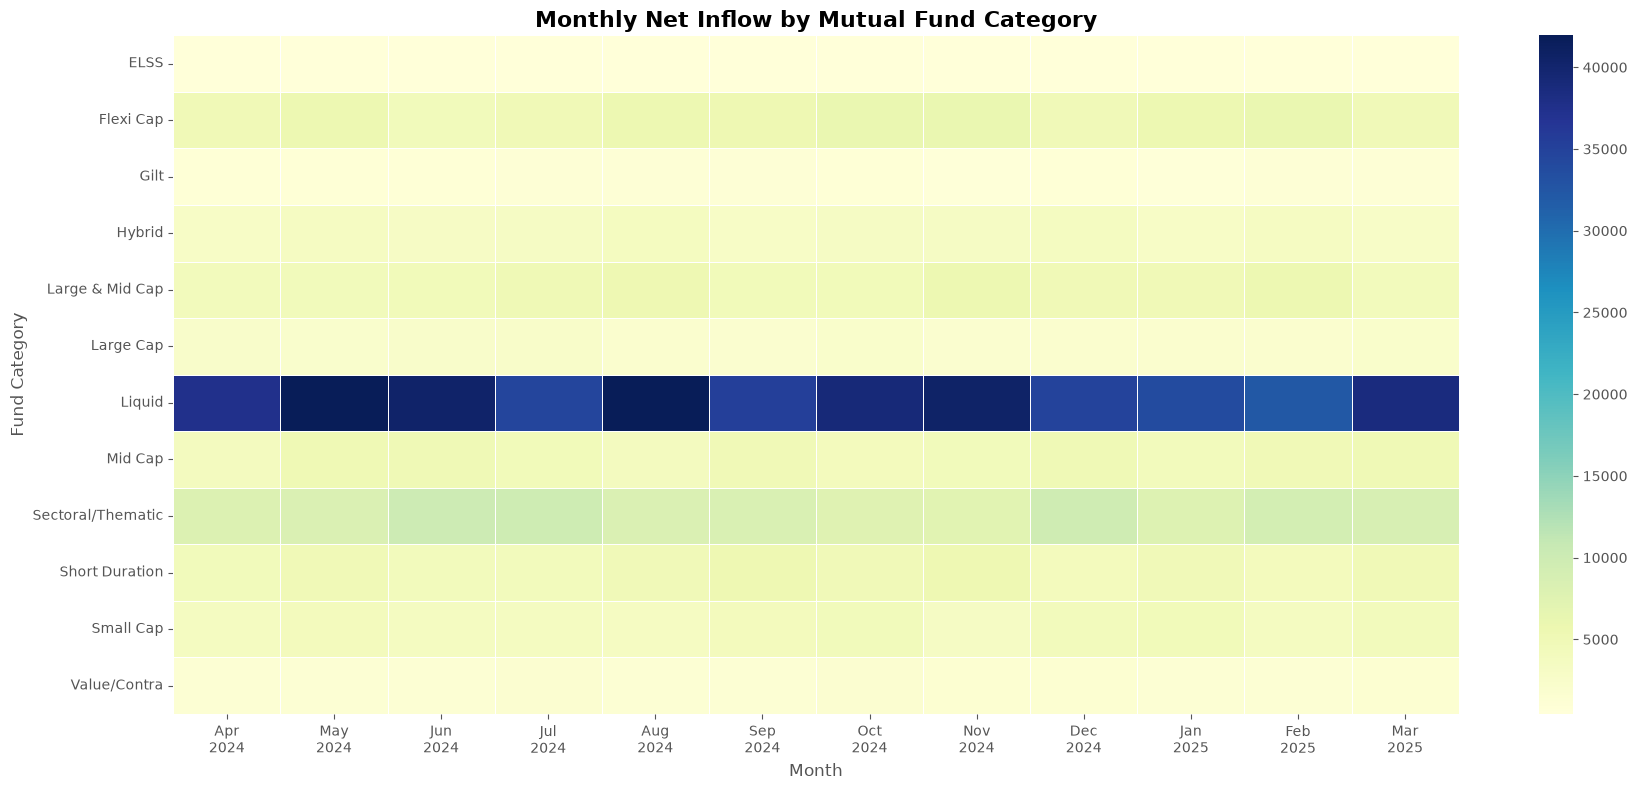

In [54]:
# Step 3 — Plot Heatmap
plt.figure(figsize=(18,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    linewidths=0.4,
    annot=False
)

plt.title(
    "Monthly Net Inflow by Mutual Fund Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

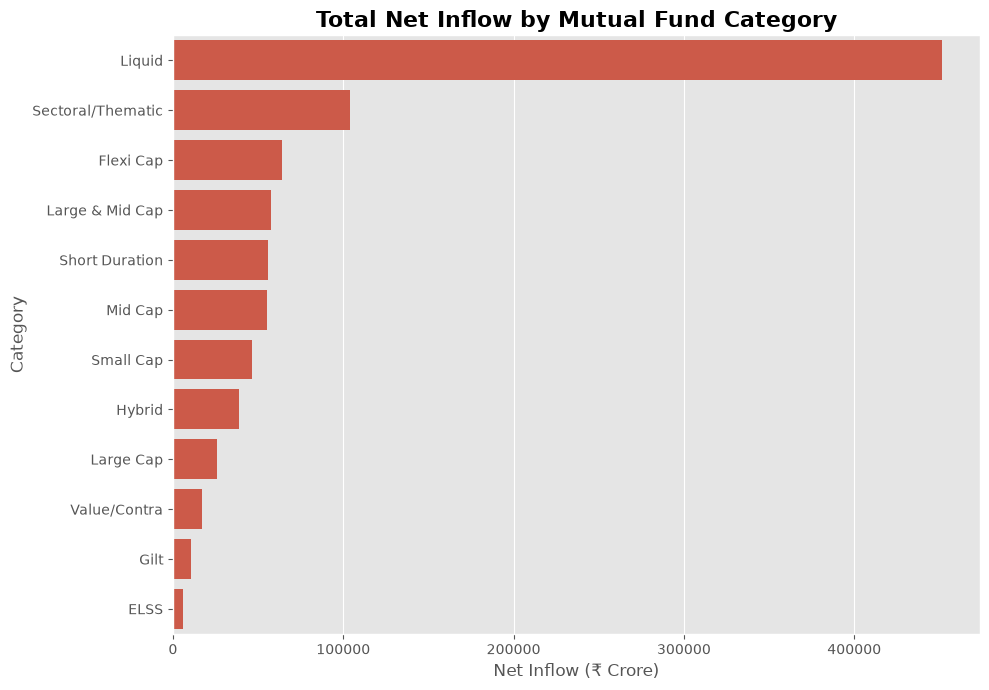

In [55]:
# Chart 9 — Total Category Inflows
# Aggregate
category_total = (
    category.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=category_total,
    x="net_inflow_crore",
    y="category"
)

plt.title(
    "Total Net Inflow by Mutual Fund Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Net Inflow (₹ Crore)")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    CHART_DIR/"category_total.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 6

Category-wise inflow analysis reveals clear investor preferences across different mutual fund categories. Equity-oriented categories consistently attracted higher net inflows than debt and hybrid categories, reflecting stronger investor confidence in long-term wealth creation. Monthly fluctuations also indicate changing market sentiment and investment behavior over time.

## 7. Investor Demographics Analysis

### Objective

Understand the demographic profile of mutual fund investors by analyzing age groups, gender distribution, and investment amounts.

**Dataset**

- 08_investor_transactions.csv

**Visualizations**

- Age Group Distribution
- Investment Amount by Age Group
- Gender Distribution

In [56]:
# Chart 10 — Investor Age Group Distribution
# first five investors by age group
age_counts = (
    transactions["age_group"]
    .value_counts()
    .reset_index()
)

age_counts.columns = ["age_group", "count"]

age_counts

# Plot

fig = px.pie(
    age_counts,
    names="age_group",
    values="count",
    hole=0.45,
    title="Investor Distribution by Age Group"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white"
)

save_plot(fig,"age_group_distribution")

fig.show()

✓ Saved age_group_distribution


In [57]:
# Chart 11 — SIP Amount by Age Group (Box Plot)
fig = px.box(
    transactions,
    x="age_group",
    y="amount_inr",
    color="age_group",
    points="outliers",
    title="Investment Amount Distribution by Age Group",
    labels={
        "amount_inr":"Investment Amount (₹)",
        "age_group":"Age Group"
    }
)

fig.update_layout(
    template="plotly_white",
    showlegend=False
)

save_plot(fig,"investment_by_age")

fig.show()

✓ Saved investment_by_age


In [59]:
# Chart 12 - Gender Distribution
gender_counts = (
    transactions["gender"]
    .value_counts()
    .reset_index()
)

gender_counts.columns = ["gender","count"]

# Plot
fig = px.pie(
    gender_counts,
    names="gender",
    values="count",
    hole=0.45,
    title="Investor Gender Distribution"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white"
)

save_plot(fig,"gender_distribution")

fig.show()

✓ Saved gender_distribution


In [60]:
# summary table
transactions.groupby("age_group").agg(
    Investors=("investor_id","count"),
    Average_Investment=("amount_inr","mean"),
    Median_Investment=("amount_inr","median")
).round(2)

,Investors,Average_Investment,Median_Investment
age_group,,,
18-25,4916,108144.71,17553.0
26-35,13463,107821.45,18523.0
36-45,8146,107003.13,17457.0
46-55,3779,107278.77,17425.0
56+,2474,105613.11,20396.5


### Insight 7

Investor demographics indicate broad participation across multiple age groups, with the largest share coming from working-age individuals. Investment amounts generally increase with age, reflecting higher earning capacity and accumulated wealth. The gender distribution provides additional insight into investor participation and can help identify opportunities for broader financial inclusion.

## 8. Geographic Distribution of Investors

### Objective

Analyze the geographic distribution of mutual fund investments across Indian states and compare investor participation between Tier-30 (T30) and Beyond-30 (B30) cities.

**Dataset**

- 08_investor_transactions.csv

**Visualizations**

- State-wise Investment Amount
- T30 vs B30 Investor Distribution

In [61]:
# Chart 13 — State-wise Investment Amount
# Step 1 : Aggregate investment amount by state.
state_investment = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_investment.head()

# Step 2 : Plot the bar chart.
fig = px.bar(
    state_investment,
    x="amount_inr",
    y="state",
    orientation="h",
    text="amount_inr",
    title="Total Investment Amount by State",
    labels={
        "amount_inr":"Investment Amount (₹)",
        "state":"State"
    }
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside"
)

save_plot(fig, "investment_by_state")

fig.show()

✓ Saved investment_by_state


In [63]:
# Chart 14 — T30 vs B30 Distribution
transactions["city_tier"].value_counts()

# Aggregate
tier_counts = (
    transactions["city_tier"]
    .value_counts()
    .reset_index()
)

tier_counts.columns = [
    "city_tier",
    "count"
]

tier_amount = (
    transactions.groupby("city_tier")["amount_inr"]
    .sum()
    .reset_index()
)

# Plot
fig = px.pie(
    tier_amount,
    names="city_tier",
    values="amount_inr",
    hole=0.5,
    title="Investment Share: T30 vs B30 Cities"
)

save_plot(fig, "tier_investment_share")

fig.show()


✓ Saved tier_investment_share


### Insight 8

Investment activity is concentrated in a few major states, indicating stronger mutual fund adoption in financially developed regions. The comparison between T30 and B30 cities highlights the distribution of investment participation, while the investment share suggests that metropolitan areas continue to account for a significant portion of total investments.

## 9. Mutual Fund Folio Growth Analysis

### Objective

Analyze the growth of mutual fund folios in India from 2022 to 2025 to understand investor participation trends across different fund categories.

**Dataset**

- 06_industry_folio_count.csv

**Visualizations**

- Total Industry Folio Growth
- Folio Composition by Fund Type

In [64]:
# Chart 15 - Total Industry Folio Growth
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [65]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Growth of Total Mutual Fund Folios (2022–2025)",
    labels={
        "month":"Month",
        "total_folios_crore":"Total Folios (Crore)"
    }
)

In [66]:
latest = folio.iloc[-1]

fig.add_annotation(
    x=native(latest["month"]),
    y=float(latest["total_folios_crore"]),
    text=f"{latest['total_folios_crore']:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="white",
    bordercolor="black"
)

In [67]:
fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

save_plot(fig,"folio_growth")

fig.show()

✓ Saved folio_growth


In [69]:
# Chart 16 - Folio Composition
folio_long = folio.melt(
    id_vars="month",
    value_vars=[
        "equity_folios_crore",
        "debt_folios_crore",
        "hybrid_folios_crore",
        "others_folios_crore"
    ],
    var_name="Fund Type",
    value_name="Folios"
)

folio_long["Fund Type"] = (
    folio_long["Fund Type"]
    .str.replace("_folios_crore","")
    .str.replace("_"," ")
    .str.title()
)

# Plot
fig = px.line(
    folio_long,
    x="month",
    y="Folios",
    color="Fund Type",
    markers=True,
    title="Growth of Mutual Fund Folios by Fund Type"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified"
)

save_plot(fig,"folio_by_type")

fig.show()

✓ Saved folio_by_type


### Insight 9

The total number of mutual fund folios increased steadily throughout the analysis period, reflecting continued expansion in retail investor participation. Equity fund folios contributed the largest share of this growth, while debt and hybrid categories exhibited comparatively moderate increases.

## 10. NAV Return Correlation Analysis

### Objective

Measure the relationship between the daily returns of selected mutual fund schemes to understand diversification opportunities and similarities in fund performance.

**Dataset**

- 02_nav_history.csv
- 01_fund_master.csv

**Visualizations**

- Correlation Heatmap of Daily Returns

In [70]:
# select 10 funds

selected_funds = (
    fund_master["amfi_code"]
    .unique()[:10]
)

selected_funds

# Step 2 — Filter NAV History
nav_selected = nav[
    nav["amfi_code"].isin(selected_funds)
].copy()

# Step 3 — Add Scheme Names
nav_selected = nav_selected.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

# Step 4 — Create NAV Matrix
nav_matrix = nav_selected.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Step 5 — Compute Daily Returns
daily_returns = nav_matrix.pct_change().dropna()

# Step 6 — Correlation matrix
corr_matrix = daily_returns.corr()

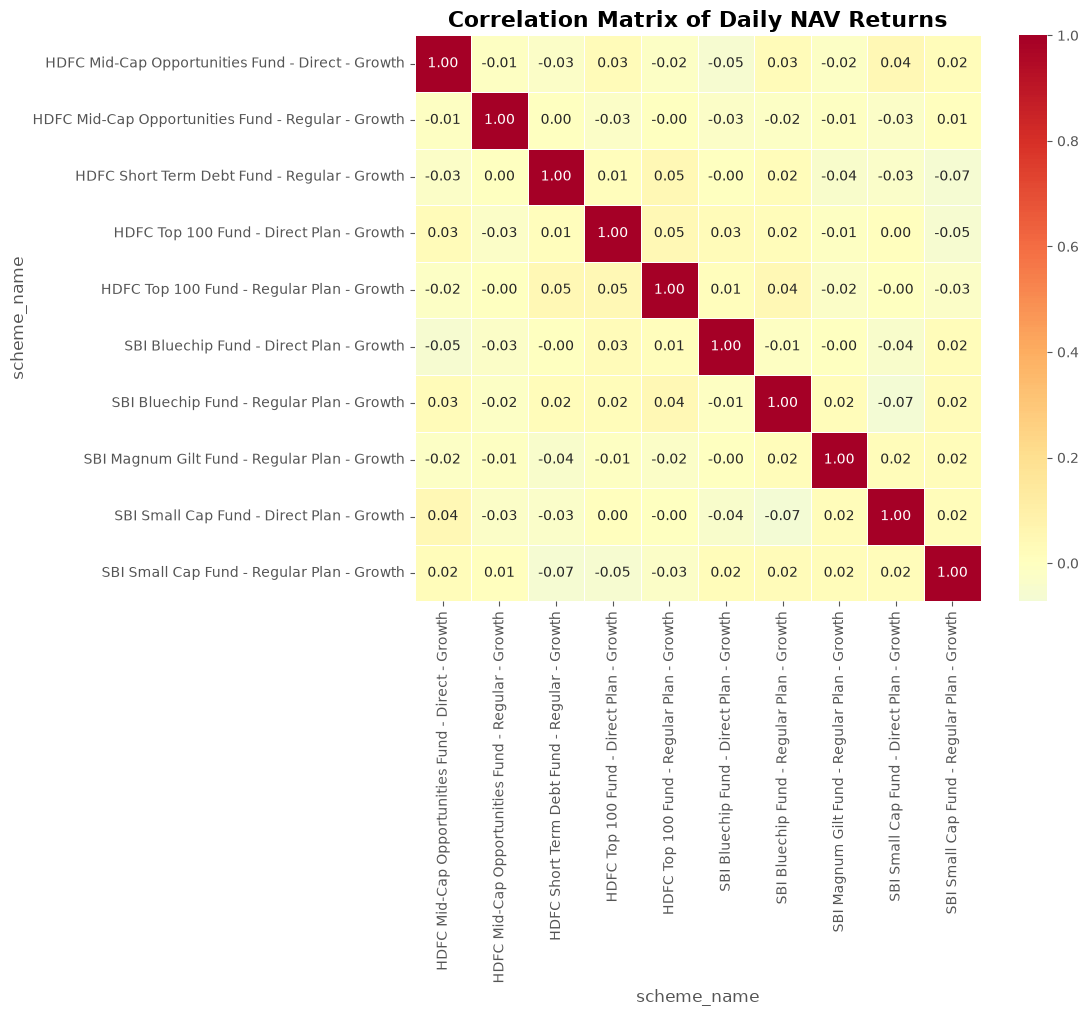

In [71]:
# Step 7 — Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5,
    fmt=".2f",
    square=True
)

plt.title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR/"nav_return_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 10

The correlation matrix shows that most large-cap equity funds exhibit moderate to high positive correlations because they are influenced by similar market movements. However, the varying correlation strengths suggest that combining different funds can still provide diversification benefits within a mutual fund portfolio.

## 11. Portfolio Sector Allocation

### Objective

Analyze the aggregate sector allocation across all equity mutual funds to identify the sectors receiving the highest portfolio allocation.

**Dataset**

- 09_portfolio_holdings.csv

**Visualizations**

- Sector Allocation Donut Chart
- Top 10 Sector Allocation

In [72]:
# Chart 17 — Sector Allocation Donut Chart

# Step 1 — Aggregate sector weights
sector_allocation = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_allocation.head()

# Step 2 — Normalize
sector_allocation["weight_pct"] = (
    sector_allocation["weight_pct"]
    / sector_allocation["weight_pct"].sum()
    * 100
)

# Step 3 — Donut Chart
fig = px.pie(
    sector_allocation,
    names="sector",
    values="weight_pct",
    hole=0.55,
    title="Aggregate Sector Allocation Across Equity Funds"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    template="plotly_white"
)

save_plot(fig, "sector_allocation")

fig.show()

✓ Saved sector_allocation


In [73]:
# Chart 18 — Top 10 Sectors
top_sector = sector_allocation.head(10)

fig = px.bar(
    top_sector,
    x="weight_pct",
    y="sector",
    orientation="h",
    text="weight_pct",
    title="Top 10 Portfolio Sectors"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

save_plot(fig, "top_sector_allocation")

fig.show()

✓ Saved top_sector_allocation


### Insight 11

Portfolio holdings are concentrated in a few dominant sectors, indicating that equity mutual funds primarily invest in industries with strong market capitalization and long-term growth potential. The sector allocation also demonstrates diversification across multiple industries, helping reduce portfolio concentration risk.

# Key EDA Findings

### 1. Consistent Growth in Mutual Fund NAVs
The majority of mutual fund schemes exhibited a long-term upward trend in Net Asset Value (NAV) between 2022 and 2025, indicating sustained market growth despite short-term volatility.

---

### 2. Industry Leadership by Large Asset Management Companies
AUM analysis showed that a small number of major Asset Management Companies (AMCs), including SBI Mutual Fund, ICICI Prudential Mutual Fund, and HDFC Mutual Fund, managed a disproportionately large share of industry assets.

---

### 3. Strong Increase in Monthly SIP Investments
Monthly SIP inflows increased steadily throughout the analysis period, reaching the highest recorded value towards the end of the dataset. This reflects growing retail investor confidence and increasing participation in disciplined investing.

---

### 4. Continuous Growth in Active SIP Accounts
The number of active SIP accounts consistently increased over time, indicating wider adoption of systematic investment plans among retail investors.

---

### 5. Equity Categories Attracted Higher Capital Inflows
Category-wise analysis revealed that equity-oriented mutual funds generally attracted higher net inflows compared to debt and hybrid categories, suggesting stronger investor preference for long-term equity investments.

---

### 6. Working-Age Investors Dominate Participation
The majority of investors belonged to working-age groups, highlighting that individuals in their prime earning years contribute significantly to mutual fund investments.

---

### 7. Investment Amounts Tend to Increase with Age
Box plot analysis indicated that older investor groups generally invested larger amounts than younger investors, likely reflecting higher disposable income and accumulated wealth.

---

### 8. Investment Activity is Concentrated in Major States
State-wise investment analysis showed that a limited number of financially developed states account for a substantial proportion of total investment activity, indicating regional concentration within the mutual fund industry.

---

### 9. Equity Funds Drive Industry Folio Growth
Industry folio analysis demonstrated consistent growth in mutual fund accounts, with equity funds contributing the largest share of new folios during the study period.

---

### 10. Most Equity Funds Exhibit Positive Correlation
Daily return correlation analysis showed that large-cap equity funds generally move in the same direction because of common exposure to overall market conditions. However, varying correlation strengths indicate opportunities for portfolio diversification.

---

### 11. Portfolio Holdings are Well Diversified Across Sectors
Sector allocation analysis revealed that mutual fund portfolios maintain exposure across multiple industries rather than concentrating investments in a single sector, helping reduce concentration risk.

---

### 12. Overall Industry Shows Healthy Long-Term Expansion
Across NAV growth, increasing AUM, rising SIP inflows, expanding folio counts, and growing investor participation, the mutual fund industry demonstrated strong long-term expansion during the analysis period.